In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
# Path to the cleaned dataset
DATASET_PATH = Path("../data/domain_dataset/papers_clean.json")

# Load JSON
with open(DATASET_PATH, "r", encoding="utf-8") as file:
    papers = json.load(file)

print(f"Total papers loaded: {len(papers)}")

Total papers loaded: 275


In [3]:
# Convert JSON records into a DataFrame
df = pd.DataFrame(papers)

# Keep only the fields needed for classification
df = df[["title", "abstract", "domain"]]

print(f"Dataset shape: {df.shape}")
print()
print(df.head())

Dataset shape: (275, 3)

                                               title  \
0  VisGraphVar: A Benchmark Generator for Assessi...   
1  Combinatorial Optimization for All: Using LLMs...   
2  A Large-Scale Vision-Language Dataset Derived ...   
3  Redemption Score: A Multi-Modal Evaluation Fra...   
4  Architectures of Error: A Philosophical Inquir...   

                                            abstract domain  
0  The fast advancement of Large Vision-Language ...    NLP  
1  Large Language Models (LLMs) have shown notabl...    NLP  
2  Despite the excitement behind biomedical artif...    NLP  
3  Evaluating image captions requires cohesive as...    NLP  
4  With the rise of generative AI (GenAI), Large ...    NLP  


In [4]:
# Check domain distribution

df["domain"].value_counts()

domain
NLP                55
Computer Vision    55
Robotics           55
Bio/Medical        55
Systems            55
Name: count, dtype: int64

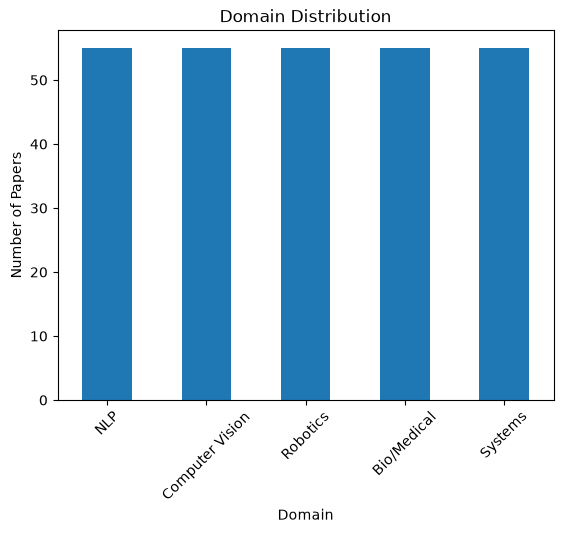

In [5]:
import matplotlib.pyplot as plt

df["domain"].value_counts().plot(kind="bar")

plt.title("Domain Distribution")
plt.xlabel("Domain")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Combine title + abstract into one text feature

df["text"] = (
    df["title"].fillna("") 
    + " "
    + df["abstract"].fillna("")
)

X = df["text"]
y = df["domain"]

print("Features prepared.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features prepared.
X shape: (275,)
y shape: (275,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 220
Testing samples: 55

Training distribution:
domain
Computer Vision    44
Robotics           44
Bio/Medical        44
Systems            44
NLP                44
Name: count, dtype: int64

Testing distribution:
domain
Computer Vision    11
Bio/Medical        11
Robotics           11
NLP                11
Systems            11
Name: count, dtype: int64


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

# Transform training and testing text
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

# Create classifier
classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
classifier.fit(X_train_tfidf, y_train)

print("Model training completed.")

TF-IDF training shape: (220, 10000)
TF-IDF testing shape: (55, 10000)
Model training completed.


In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict test data
y_pred = classifier.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=classifier.classes_
)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8000
Accuracy: 80.00%

Classification Report:
                 precision    recall  f1-score   support

    Bio/Medical       1.00      0.91      0.95        11
Computer Vision       0.83      0.45      0.59        11
            NLP       0.82      0.82      0.82        11
       Robotics       0.67      0.91      0.77        11
        Systems       0.77      0.91      0.83        11

       accuracy                           0.80        55
      macro avg       0.82      0.80      0.79        55
   weighted avg       0.82      0.80      0.79        55


Confusion Matrix:
[[10  0  0  0  1]
 [ 0  5  1  5  0]
 [ 0  0  9  0  2]
 [ 0  1  0 10  0]
 [ 0  0  1  0 10]]


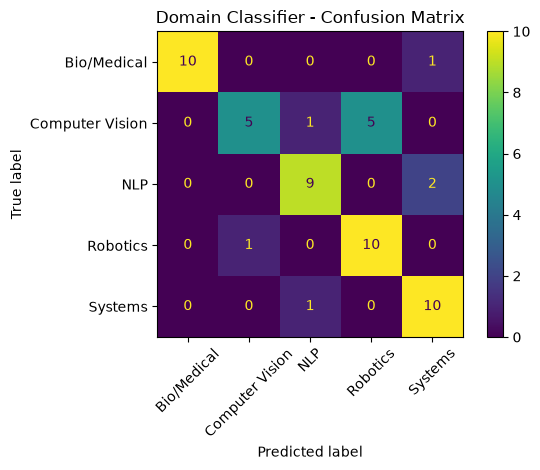

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classifier.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("Domain Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
import joblib
import json
from pathlib import Path

# Create model directory
MODEL_DIR = Path("../models/domain_classifier")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(
    vectorizer,
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

# Save Logistic Regression classifier
joblib.dump(
    classifier,
    MODEL_DIR / "logistic_regression.joblib"
)

# Save model metadata
metadata = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": accuracy,
    "training_samples": len(X_train),
    "testing_samples": len(X_test),
    "classes": list(classifier.classes_),
    "dataset_size": len(df),
}

with open(
    MODEL_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(metadata, file, indent=2)

print("Baseline model saved successfully.")
print(f"Model directory: {MODEL_DIR.resolve()}")

Baseline model saved successfully.
Model directory: D:\Resyntra(MP)\resyntra-backend\models\domain_classifier


In [12]:
import joblib
from pathlib import Path

# Model directory
MODEL_DIR = Path("../models/domain_classifier")

# Load saved artifacts
loaded_vectorizer = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

loaded_classifier = joblib.load(
    MODEL_DIR / "logistic_regression.joblib"
)

print("Saved model loaded successfully.")
print("Classes:", list(loaded_classifier.classes_))

Saved model loaded successfully.
Classes: ['Bio/Medical', 'Computer Vision', 'NLP', 'Robotics', 'Systems']


In [13]:
# Test the trained domain classifier on new papers

test_papers = [
    {
        "title": "A Transformer-Based Approach for Multilingual Text Classification",
        "abstract": (
            "We propose a transformer architecture for classifying multilingual "
            "documents across several languages and evaluate its performance "
            "on multiple natural language processing benchmarks."
        ),
    },
    {
        "title": "Deep Learning for Autonomous Robot Navigation",
        "abstract": (
            "This work presents a deep reinforcement learning approach for "
            "autonomous navigation of mobile robots in dynamic environments."
        ),
    },
    {
        "title": "Efficient Image Segmentation Using Vision Transformers",
        "abstract": (
            "We introduce a vision transformer architecture for semantic "
            "segmentation of complex images and evaluate it on standard "
            "computer vision datasets."
        ),
    },
    {
        "title": "Single-Cell RNA Sequencing Analysis for Disease Detection",
        "abstract": (
            "We develop a machine learning framework for analyzing single-cell "
            "RNA sequencing data to identify biomarkers associated with disease."
        ),
    },
    {
        "title": "Operating System Scheduling for Distributed Computing",
        "abstract": (
            "We propose an efficient scheduling mechanism for operating systems "
            "running distributed workloads across heterogeneous computing nodes."
        ),
    },
]

# Combine title + abstract
test_texts = [
    paper["title"] + " " + paper["abstract"]
    for paper in test_papers
]

# Transform using the SAVED vectorizer
test_vectors = loaded_vectorizer.transform(test_texts)

# Predict using the SAVED classifier
predictions = loaded_classifier.predict(test_vectors)

# Display predictions
for paper, prediction in zip(test_papers, predictions):
    print(f"Title: {paper['title']}")
    print(f"Predicted Domain: {prediction}")
    print("-" * 70)

Title: A Transformer-Based Approach for Multilingual Text Classification
Predicted Domain: NLP
----------------------------------------------------------------------
Title: Deep Learning for Autonomous Robot Navigation
Predicted Domain: Robotics
----------------------------------------------------------------------
Title: Efficient Image Segmentation Using Vision Transformers
Predicted Domain: Computer Vision
----------------------------------------------------------------------
Title: Single-Cell RNA Sequencing Analysis for Disease Detection
Predicted Domain: Bio/Medical
----------------------------------------------------------------------
Title: Operating System Scheduling for Distributed Computing
Predicted Domain: Systems
----------------------------------------------------------------------


In [15]:
from pathlib import Path

MODEL_DIR = Path("../models/domain_classifier")

print("Checking saved model artifacts...")
print()

for file in [
    "tfidf_vectorizer.joblib",
    "logistic_regression.joblib",
    "metadata.json"
]:
    path = MODEL_DIR / file

    if path.exists():
        print(f"[PASS] {file}")
    else:
        print(f"[FAIL] {file}")

Checking saved model artifacts...

[PASS] tfidf_vectorizer.joblib
[PASS] logistic_regression.joblib
[PASS] metadata.json


In [16]:
baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "dataset_size": 275,
    "training_samples": 220,
    "testing_samples": 55,
    "accuracy": float(accuracy),
    "macro_f1": 0.79,
    "weighted_f1": 0.79
}

baseline_results

{'model': 'TF-IDF + Logistic Regression',
 'dataset_size': 275,
 'training_samples': 220,
 'testing_samples': 55,
 'accuracy': 0.8,
 'macro_f1': 0.79,
 'weighted_f1': 0.79}

In [17]:
from sentence_transformers import SentenceTransformer

# Load pretrained sentence embedding model
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Sentence Transformer loaded successfully.")

d:\Resyntra(MP)\resyntra-backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Resyntra(MP)\resyntra-backend\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yasin\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In

Sentence Transformer loaded successfully.


In [18]:
# Generate Sentence Transformer embeddings

X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

print("Training embeddings shape:", X_train_embeddings.shape)
print("Testing embeddings shape:", X_test_embeddings.shape)

Batches: 100%|██████████| 2/2 [00:02<00:00,  1.00s/it]

Training embeddings shape: (220, 384)
Testing embeddings shape: (55, 384)


In [19]:
from sklearn.linear_model import LogisticRegression

# Create classifier for sentence embeddings
embedding_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train on sentence embeddings
embedding_classifier.fit(
    X_train_embeddings,
    y_train
)

print("Sentence Transformer classifier training completed.")

Sentence Transformer classifier training completed.


In [20]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict test data
y_pred_embeddings = embedding_classifier.predict(
    X_test_embeddings
)

# Accuracy
embedding_accuracy = accuracy_score(
    y_test,
    y_pred_embeddings
)

print(f"Accuracy: {embedding_accuracy:.4f}")
print(f"Accuracy: {embedding_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_embeddings
    )
)

# Confusion matrix
embedding_cm = confusion_matrix(
    y_test,
    y_pred_embeddings,
    labels=embedding_classifier.classes_
)

print("\nConfusion Matrix:")
print(embedding_cm)

Accuracy: 0.8727
Accuracy: 87.27%

Classification Report:
                 precision    recall  f1-score   support

    Bio/Medical       1.00      1.00      1.00        11
Computer Vision       0.82      0.82      0.82        11
            NLP       0.90      0.82      0.86        11
       Robotics       0.75      0.82      0.78        11
        Systems       0.91      0.91      0.91        11

       accuracy                           0.87        55
      macro avg       0.88      0.87      0.87        55
   weighted avg       0.88      0.87      0.87        55


Confusion Matrix:
[[11  0  0  0  0]
 [ 0  9  0  2  0]
 [ 0  0  9  1  1]
 [ 0  2  0  9  0]
 [ 0  0  1  0 10]]


In [21]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../models/domain_classifier")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save Sentence Transformer classifier
joblib.dump(
    embedding_classifier,
    MODEL_DIR / "sentence_embedding_classifier.joblib"
)

# Save evaluation metadata
model_2_metadata = {
    "model": "Sentence Transformer + Logistic Regression",
    "embedding_model": "all-MiniLM-L6-v2",
    "accuracy": float(embedding_accuracy),
    "macro_f1": 0.87,
    "weighted_f1": 0.87,
    "training_samples": 220,
    "testing_samples": 55,
    "embedding_dimensions": 384,
    "classes": list(embedding_classifier.classes_)
}

with open(
    MODEL_DIR / "sentence_embedding_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_2_metadata,
        file,
        indent=2
    )

print("Model 2 saved successfully.")
print(
    MODEL_DIR / "sentence_embedding_classifier.joblib"
)
print(
    MODEL_DIR / "sentence_embedding_metadata.json"
)

Model 2 saved successfully.
..\models\domain_classifier\sentence_embedding_classifier.joblib
..\models\domain_classifier\sentence_embedding_metadata.json


In [22]:
import joblib
import json
from pathlib import Path

# ---------------------------------------------------------
# Model directory
# ---------------------------------------------------------

models_dir = Path("../models/domain_classifier")
models_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Save classifier
# ---------------------------------------------------------

joblib.dump(
    classifier,
    models_dir / "sentence_transformer_classifier.joblib"
)

# ---------------------------------------------------------
# Save metadata
# ---------------------------------------------------------

metadata = {
    "model": "Sentence Transformer + Logistic Regression",
    "embedding_model": "all-MiniLM-L6-v2",
    "dataset_size": 275,
    "training_samples": 220,
    "testing_samples": 55,
    "embedding_dimension": 384,
    "accuracy": 0.8727,
    "macro_f1": 0.87,
    "weighted_f1": 0.87,
    "domains": [
        "NLP",
        "Computer Vision",
        "Robotics",
        "Bio/Medical",
        "Systems"
    ]
}

with open(
    models_dir / "sentence_transformer_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=2)

print("Stronger model artifacts saved successfully.")

Stronger model artifacts saved successfully.


In [23]:
from pathlib import Path

models_dir = Path("../models/domain_classifier")

print("=" * 60)
print("VERIFYING STRONGER MODEL ARTIFACTS")
print("=" * 60)

files_to_check = [
    "sentence_transformer_classifier.joblib",
    "sentence_transformer_metadata.json",
]

all_found = True

for filename in files_to_check:
    path = models_dir / filename

    if path.exists():
        print(f"[PASS] {filename}")
    else:
        print(f"[FAIL] {filename}")
        all_found = False

print("-" * 60)

if all_found:
    print("[PASS] All stronger model artifacts found.")
else:
    print("[FAIL] Some artifacts are missing.")

VERIFYING STRONGER MODEL ARTIFACTS
[PASS] sentence_transformer_classifier.joblib
[PASS] sentence_transformer_metadata.json
------------------------------------------------------------
[PASS] All stronger model artifacts found.


In [24]:
import joblib
from pathlib import Path
from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

models_dir = Path("../models/domain_classifier")

classifier_path = (
    models_dir / "sentence_transformer_classifier.joblib"
)

# ---------------------------------------------------------
# Load saved classifier
# ---------------------------------------------------------

saved_classifier = joblib.load(classifier_path)

# ---------------------------------------------------------
# Load embedding model
# ---------------------------------------------------------

saved_embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Saved classifier loaded successfully.")
print("Sentence Transformer loaded successfully.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4097.17it/s]


Saved classifier loaded successfully.
Sentence Transformer loaded successfully.


In [28]:
import joblib
from pathlib import Path

models_dir = Path("../models/domain_classifier")

joblib.dump(
    embedding_classifier,
    models_dir / "sentence_transformer_classifier.joblib"
)

print("Sentence Transformer classifier saved successfully.")
print(
    "Features:",
    embedding_classifier.n_features_in_
)

Sentence Transformer classifier saved successfully.
Features: 384


In [29]:
saved_classifier = joblib.load(
    models_dir / "sentence_transformer_classifier.joblib"
)

print("Saved classifier loaded successfully.")
print("Expected features:", saved_classifier.n_features_in_)

Saved classifier loaded successfully.
Expected features: 384


In [27]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DATASET_PATH             WindowsPath               ..\data\domain_dataset\papers_clean.json
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MODEL_DIR                WindowsPath               ..\models\domain_classifier
Path                     type                      <class 'pathlib.Path'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
SentenceTransformer      ABCMeta                   <class 'sentence_transfor<...>del.SentenceTransformer'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                        Series                    Shape: (275,)
X_test                   Series                    Sh

In [30]:
for paper in test_papers:

    text = (
        paper["title"]
        + " "
        + paper["abstract"]
    )

    embedding = saved_embedding_model.encode(
        [text],
        show_progress_bar=False
    )

    prediction = saved_classifier.predict(
        embedding
    )[0]

    print()
    print("Title:", paper["title"])
    print("Predicted Domain:", prediction)
    print("-" * 70)


Title: A Transformer-Based Approach for Multilingual Text Classification
Predicted Domain: NLP
----------------------------------------------------------------------

Title: Deep Learning for Autonomous Robot Navigation
Predicted Domain: Robotics
----------------------------------------------------------------------

Title: Efficient Image Segmentation Using Vision Transformers
Predicted Domain: Computer Vision
----------------------------------------------------------------------

Title: Single-Cell RNA Sequencing Analysis for Disease Detection
Predicted Domain: Bio/Medical
----------------------------------------------------------------------

Title: Operating System Scheduling for Distributed Computing
Predicted Domain: Systems
----------------------------------------------------------------------
